# Collaborative SVG vibe coding analysis

This notebook reads the simulated PsyNet export and summarizes chain progression, generator prompt isolation, selector behavior, and independent evaluator ratings.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 50
base = Path("../../code/collaborative_svg_vibe_coding/data/simulated_data/regular/data")
vibe = pd.read_csv(base / "VibeTrial.csv")
evaluator = pd.read_csv(base / "EvaluatorTrial.csv")
print(f"Loaded {len(vibe)} chain trials and {len(evaluator)} evaluator trials.")

Loaded 18 chain trials and 6 evaluator trials.


In [2]:
chain_cols = ["participant_id", "chain_iteration", "reference_id", "condition", "instructor_role", "selector_role", "candidate_svg_id", "selected_svg_id", "selector_choice", "candidate_render_status", "selected_render_status"]
chain = vibe[chain_cols].sort_values(["participant_id", "chain_iteration"])
chain.head(9)

,participant_id,chain_iteration,reference_id,condition,instructor_role,selector_role,candidate_svg_id,selected_svg_id,selector_choice,candidate_render_status,selected_render_status
0,1,1,cat,human-led,human,none,svg_a0d35fbdba83,svg_a0d35fbdba83,candidate,rendered,rendered
1,1,2,cat,hybrid,ai,human,svg_34214b9273a7,svg_a0d35fbdba83,previous,rendered,rendered
2,1,3,cat,ai-led,ai,ai,svg_cf27ba7de1c3,svg_cf27ba7de1c3,candidate,rendered,rendered
3,2,1,cat,human-led,human,none,svg_a0d35fbdba83,svg_a0d35fbdba83,candidate,rendered,rendered
4,2,2,cat,hybrid,ai,human,svg_34214b9273a7,svg_a0d35fbdba83,previous,rendered,rendered
5,2,3,cat,ai-led,ai,ai,svg_cf27ba7de1c3,svg_cf27ba7de1c3,candidate,rendered,rendered
6,3,1,cat,human-led,human,none,svg_a0d35fbdba83,svg_a0d35fbdba83,candidate,rendered,rendered
7,3,2,cat,hybrid,ai,human,svg_34214b9273a7,svg_a0d35fbdba83,previous,rendered,rendered
8,3,3,cat,ai-led,ai,ai,svg_cf27ba7de1c3,svg_cf27ba7de1c3,candidate,rendered,rendered


In [3]:
role_summary = chain.groupby(["condition", "instructor_role", "selector_role", "candidate_render_status", "selected_render_status"]).size().reset_index(name="n_trials")
role_summary

,condition,instructor_role,selector_role,candidate_render_status,selected_render_status,n_trials
0,ai-led,ai,ai,rendered,rendered,6
1,human-led,human,none,rendered,rendered,6
2,hybrid,ai,human,rendered,rendered,6


In [4]:
prompt_metadata = vibe["prompt_metadata"].apply(json.loads)
prompt_checks = pd.DataFrame({
    "reference_id_visible_to_generator": prompt_metadata.apply(lambda x: x["reference_id_visible_to_generator"]),
    "previous_svg_visible_to_generator": prompt_metadata.apply(lambda x: x["previous_svg_visible_to_generator"]),
    "iteration_visible_to_generator": prompt_metadata.apply(lambda x: x["iteration_visible_to_generator"]),
    "visible_fields": prompt_metadata.apply(lambda x: ", ".join(x["generator_visible_fields"])),
})
prompt_checks.drop_duplicates()

,reference_id_visible_to_generator,previous_svg_visible_to_generator,iteration_visible_to_generator,visible_fields
0,False,False,False,"system, high_level_instruction"


In [5]:
selector_counts = chain.groupby(["chain_iteration", "selector_choice"]).size().unstack(fill_value=0)
selector_counts

selector_choice,candidate,previous
chain_iteration,,
1,6,0
2,0,6
3,6,0


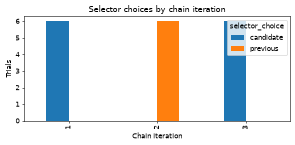

In [6]:
ax = selector_counts.plot(kind="bar", figsize=(6, 3), title="Selector choices by chain iteration")
ax.set_xlabel("Chain iteration")
ax.set_ylabel("Trials")
plt.tight_layout()

In [7]:
eval_cols = ["participant_id", "reference_id", "candidate_svg_id", "similarity_rating", "condition_visible", "render_status"]
eval_summary = evaluator[eval_cols]
eval_summary.head()

,participant_id,reference_id,candidate_svg_id,similarity_rating,condition_visible,render_status
0,1,cat,svg_cf27ba7de1c3,6,False,rendered
1,2,cat,svg_cf27ba7de1c3,6,False,rendered
2,3,cat,svg_cf27ba7de1c3,6,False,rendered
3,4,cat,svg_cf27ba7de1c3,6,False,rendered
4,5,cat,svg_cf27ba7de1c3,6,False,rendered


In [8]:
rating_summary = eval_summary.groupby(["reference_id", "candidate_svg_id", "condition_visible", "render_status"]).agg(n_ratings=("similarity_rating", "size"), mean_similarity=("similarity_rating", "mean")).reset_index()
rating_summary

,reference_id,candidate_svg_id,condition_visible,render_status,n_ratings,mean_similarity
0,cat,svg_cf27ba7de1c3,False,rendered,6,6.0


## Interpretation

The simulated export contains three collaborative SVG iterations per bot participant and one independent evaluator trial per bot participant. The chain trials cover human-led, hybrid, and AI-led role assignments, all generated SVG candidates rendered successfully, and the generator prompt metadata shows that reference identifiers, previous SVG state, and iteration numbers were not visible to the code generator. The evaluator table stores ratings without exposing condition labels.